In [1]:
import sys
import os

# Find the project root (Speciale_Kode)
current_dir = os.getcwd()
project_root = current_dir

# Looks for "Speciale_Kode" folder:
while os.path.basename(project_root) != "Speciale_Kode":
    project_root = os.path.dirname(project_root)

# Add to Python path
if project_root not in sys.path:
    sys.path.append(project_root)

In [2]:
import numpy as np

from sklearn.metrics import mean_squared_error, mean_absolute_error

def smape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    denominator = np.abs(y_true) + np.abs(y_pred)
    mask = denominator != 0

    values = np.zeros_like(y_true, dtype=float)
    values[mask] = 2 * np.abs(y_pred[mask] - y_true[mask]) / denominator[mask]

    return 100 * np.mean(values)

In [6]:
baseline_folder = os.path.join(project_root, "Baseline")

naive_folder = os.path.join(baseline_folder, "Naive")
MA_folder = os.path.join(baseline_folder, "MovingAverage")
seasonal_folder = os.path.join(baseline_folder, "Seasonal")

In [7]:
import pandas as pd

# Get daily SMAPE for 2025 for Naive Persistence

filename_naive_DK1 = "DK1_daily_results_naive.csv"
filepath_naive_DK1 = os.path.join(naive_folder, filename_naive_DK1)

df_naive_DK1 = pd.read_csv(filepath_naive_DK1)

column = "Date"

xpoints = df_naive_DK1[column].values.tolist()

column = "daily_smape"

naive_DK1 = df_naive_DK1[column].values.tolist()

filename_naive_DK2 = "DK2_daily_results_naive.csv"
filepath_naive_DK2 = os.path.join(naive_folder, filename_naive_DK2)

df_naive_DK2 = pd.read_csv(filepath_naive_DK2)

column = "daily_smape"

naive_DK2 = df_naive_DK2[column].values.tolist()

In [8]:
# Get daily SMAPE for 2025 for Moving Average

filename_MA_DK1 = "DK1_daily_results_MA.csv"
filepath_MA_DK1 = os.path.join(MA_folder, filename_MA_DK1)

df_MA_DK1 = pd.read_csv(filepath_MA_DK1)

column = "daily_smape"

MA_DK1 = df_MA_DK1[column].values.tolist()

filename_MA_DK2 = "DK2_daily_results_MA.csv"
filepath_MA_DK2 = os.path.join(MA_folder, filename_MA_DK2)

df_MA_DK2 = pd.read_csv(filepath_MA_DK2)

column = "daily_smape"

MA_DK2 = df_MA_DK2[column].values.tolist()

In [9]:
# Get daily SMAPE for 2025 for Seasonal Naive

filename_seasonal_DK1 = "DK1_daily_results_seasonal.csv"
filepath_seasonal_DK1 = os.path.join(seasonal_folder, filename_seasonal_DK1)

df_seasonal_DK1 = pd.read_csv(filepath_seasonal_DK1)

column = "daily_smape"

seasonal_DK1 = df_seasonal_DK1[column].values.tolist()

filename_seasonal_DK2 = "DK2_daily_results_seasonal.csv"
filepath_seasonal_DK2 = os.path.join(seasonal_folder, filename_seasonal_DK2)

df_seasonal_DK2 = pd.read_csv(filepath_seasonal_DK2)

column = "daily_smape"

seasonal_DK2 = df_seasonal_DK2[column].values.tolist()

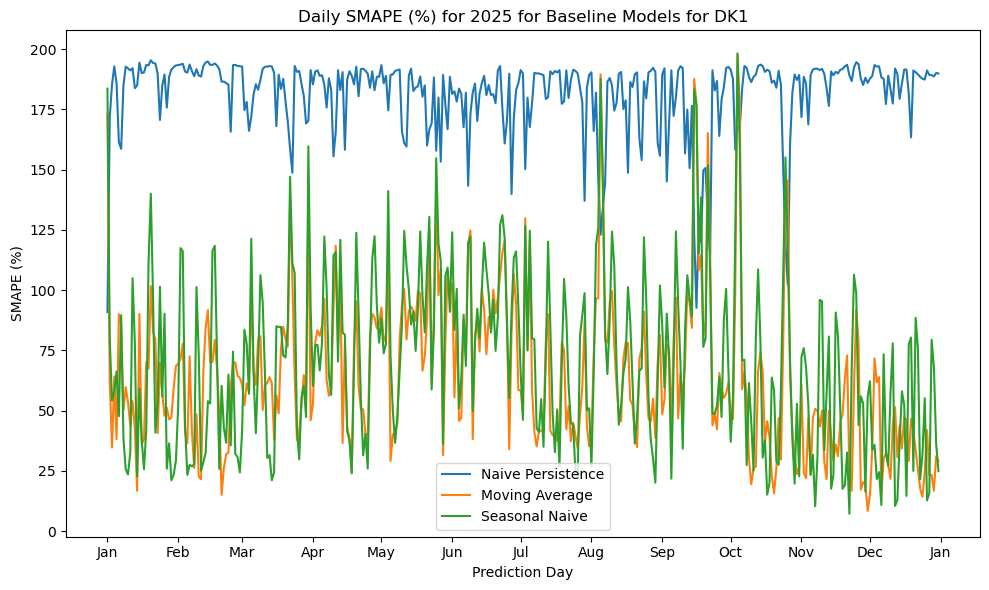

In [52]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

xpoints_dt = pd.to_datetime(xpoints)

# Generating a plot for baseline DK1 for 2025 daily SMAPE

plt.figure(figsize=(10, 6))
plt.plot(xpoints, naive_DK1, label = "Naive Persistence")
plt.plot(xpoints, MA_DK1, label = "Moving Average")
plt.plot(xpoints, seasonal_DK1, label = "Seasonal Naive")
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b'))
plt.xlabel('Prediction Day')
plt.ylabel('SMAPE (%)')
plt.title('Daily SMAPE (%) for 2025 for Baseline Models for DK1')
plt.legend()
plt.tight_layout()
plt.show()

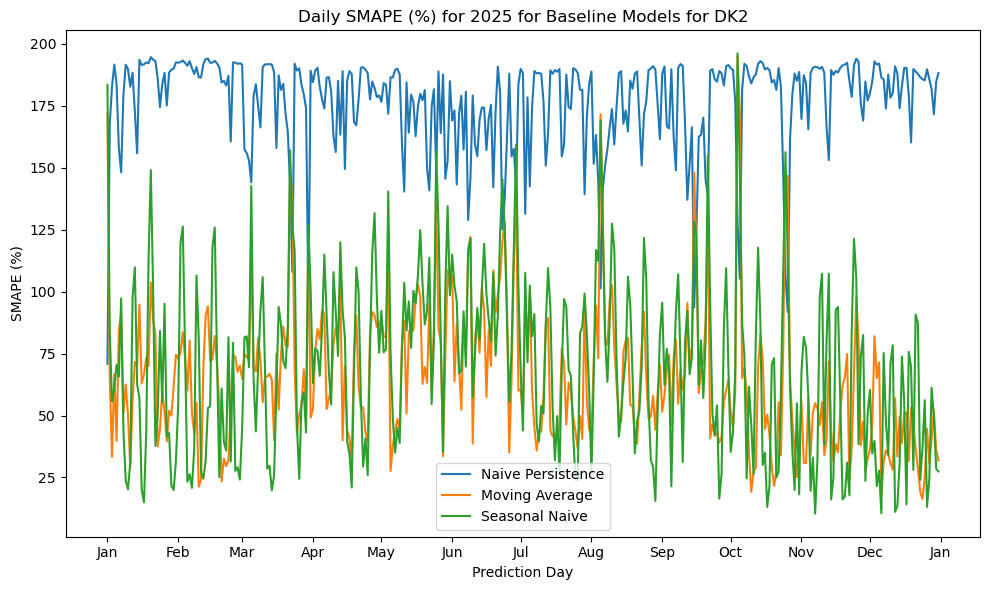

In [51]:
# Generating a plot for baseline DK2 for 2025 daily SMAPE

plt.figure(figsize=(10, 6))
plt.plot(xpoints, naive_DK2, label = "Naive Persistence")
plt.plot(xpoints, MA_DK2, label = "Moving Average")
plt.plot(xpoints, seasonal_DK2, label = "Seasonal Naive")
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b'))
plt.xlabel('Prediction Day')
plt.ylabel('SMAPE (%)')
plt.title('Daily SMAPE (%) for 2025 for Baseline Models for DK2')
plt.legend()
plt.tight_layout()
plt.show()

In [3]:
# File paths for shallow learners

shallow_folder = os.path.join(project_root, "Shallow learners")

final_eval_folder = os.path.join(shallow_folder, "Final_eval")

In [ ]:
# Read results from Lasso Linear Regression

filename_lasso_DK1 = "DK1_Lasso_predictions2.csv"
filepath_lasso_DK1 = os.path.join(final_eval_folder, filename_lasso_DK1)

df_lasso_DK1 = pd.read_csv(filepath_lasso_DK1, decimal = ",")

DK1_actuals = df_lasso_DK1["DKPrice"].values.tolist()

lasso_DK1_preds = df_lasso_DK1["Prediction"].values.tolist()

lasso_DK1_SMAPE = []

for i in range(0, len(lasso_DK1_preds), 24):
    actuals_segment = DK1_actuals[i:i+24]
    preds_segment = lasso_DK1_preds[i:i+24]
    smape_val = smape(actuals_segment, preds_segment)
    lasso_DK1_SMAPE.append(smape_val)

filename_lasso_DK2 = "DK2_Lasso_predictions2.csv"
filepath_lasso_DK2 = os.path.join(final_eval_folder, filename_lasso_DK2)

df_lasso_DK2 = pd.read_csv(filepath_lasso_DK2, decimal = ",")

DK2_actuals = df_lasso_DK2["DKPrice"].values.tolist()

lasso_DK2_preds = df_lasso_DK2["Prediction"].values.tolist()

lasso_DK2_SMAPE = []

for i in range(0, len(lasso_DK2_preds), 24):
    actuals_segment = DK2_actuals[i:i+24]
    preds_segment = lasso_DK2_preds[i:i+24]
    smape_val = smape(actuals_segment, preds_segment)
    lasso_DK2_SMAPE.append(smape_val)

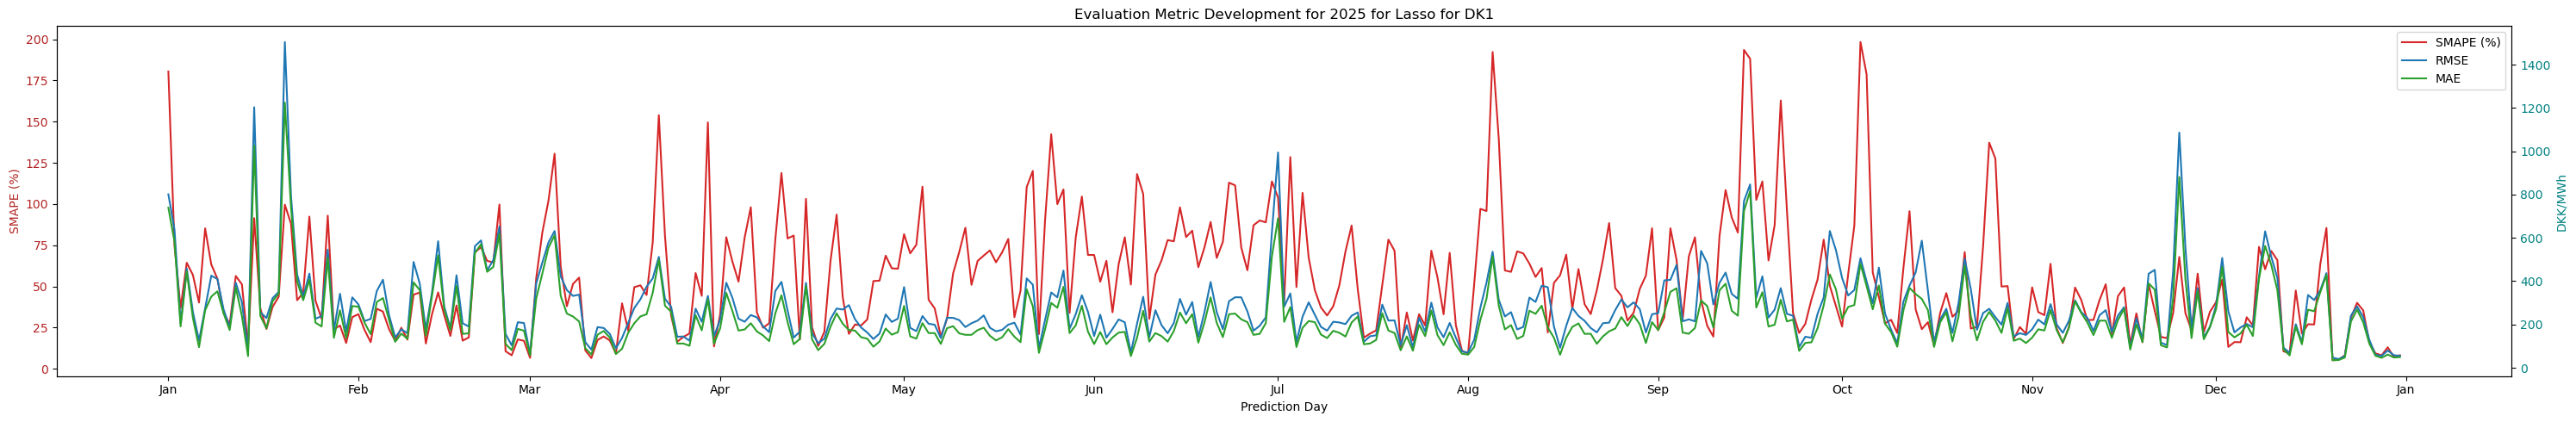

In [21]:
# Read results from Lasso Linear Regression

import pandas as pd
import matplotlib.pyplot as plt

import matplotlib.dates as mdates

xpoints_dt = pd.to_datetime(xpoints)

filename_lasso_DK1 = "DK1_Lasso_predictions2.csv"
filepath_lasso_DK1 = os.path.join(final_eval_folder, filename_lasso_DK1)

df_lasso_DK1 = pd.read_csv(filepath_lasso_DK1, decimal = ",")

DK1_actuals = df_lasso_DK1["DKPrice"].values.tolist()

lasso_DK1_preds = df_lasso_DK1["Prediction"].values.tolist()

lasso_DK1_SMAPE = []
lasso_DK1_RMSE = []
lasso_DK1_MAE = []

for i in range(0, len(lasso_DK1_preds), 24):
    actuals_segment = DK1_actuals[i:i+24]
    preds_segment = lasso_DK1_preds[i:i+24]
    smape_val = smape(actuals_segment, preds_segment)
    rmse_val = np.sqrt(mean_squared_error(actuals_segment, preds_segment))
    mae_val = mean_absolute_error(actuals_segment, preds_segment)
    lasso_DK1_SMAPE.append(smape_val)
    lasso_DK1_RMSE.append(rmse_val)
    lasso_DK1_MAE.append(mae_val)

fig, ax1 = plt.subplots(figsize = (30, 5))
color_smape = 'tab:red'
color_rmse = 'tab:blue'
color_mae = 'tab:green'
ax1.set_xlabel('Prediction Day')
ax1.set_ylabel('SMAPE (%)', color = 'firebrick')
line1, = ax1.plot(xpoints, lasso_DK1_SMAPE, label = "SMAPE (%)", color = color_smape)
ax1.tick_params(axis = 'y', labelcolor = 'firebrick')

ax2 = ax1.twinx()

color = 'tab:blue'
ax2.set_ylabel('DKK/MWh', color = 'teal')
line2, = ax2.plot(xpoints, lasso_DK1_RMSE, label = "RMSE", color = color_rmse)
line3, = ax2.plot(xpoints, lasso_DK1_MAE, label = "MAE", color = color_mae)
ax2.tick_params(axis = 'y', labelcolor = 'teal')

lines = [line1, line2, line3]
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc = 'upper right')

ax1.xaxis.set_major_locator(mdates.MonthLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
plt.title("Evaluation Metric Development for 2025 for Lasso for DK1")
fig.tight_layout()
plt.show()

filename_lasso_DK2 = "DK2_Lasso_predictions2.csv"
filepath_lasso_DK2 = os.path.join(final_eval_folder, filename_lasso_DK2)

df_lasso_DK2 = pd.read_csv(filepath_lasso_DK2, decimal = ",")

DK2_actuals = df_lasso_DK2["DKPrice"].values.tolist()

lasso_DK2_preds = df_lasso_DK2["Prediction"].values.tolist()

lasso_DK2_SMAPE = []

for i in range(0, len(lasso_DK2_preds), 24):
    actuals_segment = DK2_actuals[i:i+24]
    preds_segment = lasso_DK2_preds[i:i+24]
    smape_val = smape(actuals_segment, preds_segment)
    lasso_DK2_SMAPE.append(smape_val)

In [42]:
# Read results from SVR

filename_SVR_DK1 = "DK1_SVR_predictions.csv"
filepath_SVR_DK1 = os.path.join(final_eval_folder, filename_SVR_DK1)

df_SVR_DK1 = pd.read_csv(filepath_SVR_DK1, decimal = ",")

SVR_DK1_preds = df_SVR_DK1["Prediction"].values.tolist()

SVR_DK1_SMAPE = []

for i in range(0, len(SVR_DK1_preds), 24):
    actuals_segment = DK1_actuals[i:i+24]
    preds_segment = SVR_DK1_preds[i:i+24]
    smape_val = smape(actuals_segment, preds_segment)
    SVR_DK1_SMAPE.append(smape_val)

filename_SVR_DK2 = "DK2_SVR_predictions.csv"
filepath_SVR_DK2 = os.path.join(final_eval_folder, filename_SVR_DK2)

df_SVR_DK2 = pd.read_csv(filepath_SVR_DK2, decimal = ",")

SVR_DK2_preds = df_SVR_DK2["Prediction"].values.tolist()

SVR_DK2_SMAPE = []

for i in range(0, len(SVR_DK2_preds), 24):
    actuals_segment = DK2_actuals[i:i+24]
    preds_segment = SVR_DK2_preds[i:i+24]
    smape_val = smape(actuals_segment, preds_segment)
    SVR_DK2_SMAPE.append(smape_val)

In [43]:
# Read results from XGB

filename_XGB_DK1 = "DK1_XGBoost_predictions2.csv"
filepath_XGB_DK1 = os.path.join(final_eval_folder, filename_XGB_DK1)

df_XGB_DK1 = pd.read_csv(filepath_XGB_DK1, decimal = ",")

XGB_DK1_preds = df_XGB_DK1["Prediction"].values.tolist()

XGB_DK1_SMAPE = []

for i in range(0, len(XGB_DK1_preds), 24):
    actuals_segment = DK1_actuals[i:i+24]
    preds_segment = XGB_DK1_preds[i:i+24]
    smape_val = smape(actuals_segment, preds_segment)
    XGB_DK1_SMAPE.append(smape_val)

filename_XGB_DK2 = "DK2_XGBoost_predictions2.csv"
filepath_XGB_DK2 = os.path.join(final_eval_folder, filename_XGB_DK2)

df_XGB_DK2 = pd.read_csv(filepath_XGB_DK2, decimal = ",")

XGB_DK2_preds = df_XGB_DK2["Prediction"].values.tolist()

XGB_DK2_SMAPE = []

for i in range(0, len(XGB_DK2_preds), 24):
    actuals_segment = DK2_actuals[i:i+24]
    preds_segment = XGB_DK2_preds[i:i+24]
    smape_val = smape(actuals_segment, preds_segment)
    XGB_DK2_SMAPE.append(smape_val)

In [44]:
# Read results from LightGBM

filename_lightgbm_DK1 = "DK1_LightGBM_predictions2.csv"
filepath_lightgbm_DK1 = os.path.join(final_eval_folder, filename_lightgbm_DK1)

df_lightgbm_DK1 = pd.read_csv(filepath_lightgbm_DK1, decimal = ",")

lightgbm_DK1_preds = df_lightgbm_DK1["Prediction"].values.tolist()

lightgbm_DK1_SMAPE = []

for i in range(0, len(lightgbm_DK1_preds), 24):
    actuals_segment = DK1_actuals[i:i+24]
    preds_segment = lightgbm_DK1_preds[i:i+24]
    smape_val = smape(actuals_segment, preds_segment)
    lightgbm_DK1_SMAPE.append(smape_val)

filename_lightgbm_DK2 = "DK2_LightGBM_predictions2.csv"
filepath_lightgbm_DK2 = os.path.join(final_eval_folder, filename_lightgbm_DK2)

df_lightgbm_DK2 = pd.read_csv(filepath_lightgbm_DK2, decimal = ",")

lightgbm_DK2_preds = df_lightgbm_DK2["Prediction"].values.tolist()

lightgbm_DK2_SMAPE = []

for i in range(0, len(lightgbm_DK2_preds), 24):
    actuals_segment = DK2_actuals[i:i+24]
    preds_segment = lightgbm_DK2_preds[i:i+24]
    smape_val = smape(actuals_segment, preds_segment)
    lightgbm_DK2_SMAPE.append(smape_val)

In [45]:
# Read results from Random Forest

filename_RF_DK1 = "DK1_RF_predictions2.csv"
filepath_RF_DK1 = os.path.join(final_eval_folder, filename_RF_DK1)

df_RF_DK1 = pd.read_csv(filepath_RF_DK1, decimal = ",")

RF_DK1_preds = df_RF_DK1["Prediction"].values.tolist()

RF_DK1_SMAPE = []

for i in range(0, len(RF_DK1_preds), 24):
    actuals_segment = DK1_actuals[i:i+24]
    preds_segment = RF_DK1_preds[i:i+24]
    smape_val = smape(actuals_segment, preds_segment)
    RF_DK1_SMAPE.append(smape_val)

filename_RF_DK2 = "DK2_RF_predictions2.csv"
filepath_RF_DK2 = os.path.join(final_eval_folder, filename_RF_DK2)

df_RF_DK2 = pd.read_csv(filepath_RF_DK2, decimal = ",")

RF_DK2_preds = df_RF_DK2["Prediction"].values.tolist()

RF_DK2_SMAPE = []

for i in range(0, len(RF_DK2_preds), 24):
    actuals_segment = DK2_actuals[i:i+24]
    preds_segment = RF_DK2_preds[i:i+24]
    smape_val = smape(actuals_segment, preds_segment)
    RF_DK2_SMAPE.append(smape_val)

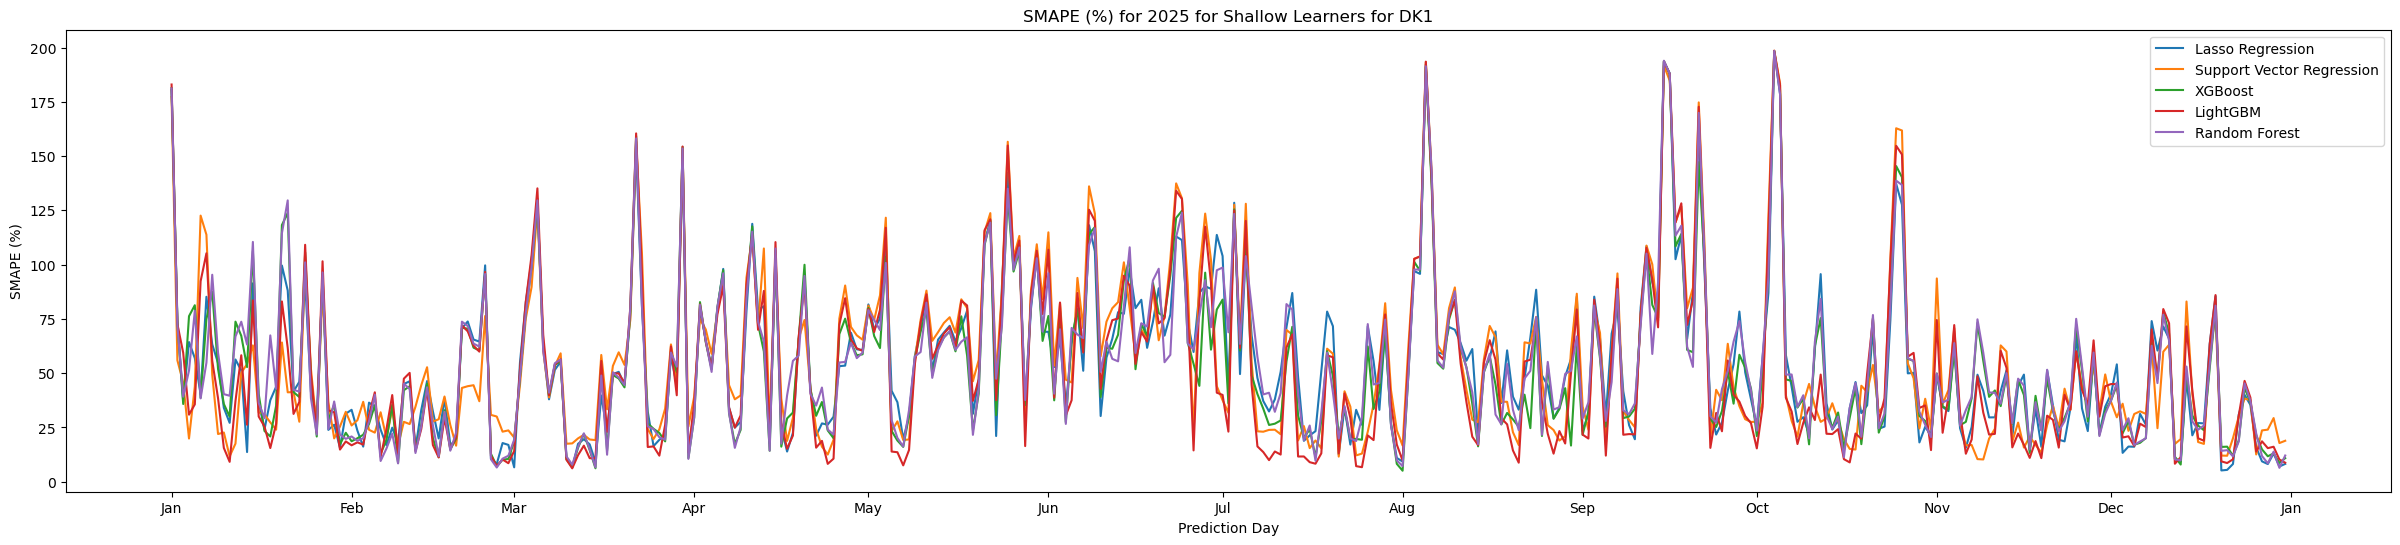

In [58]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

xpoints_dt = pd.to_datetime(xpoints)

# Generating a plot for shallow DK1 2025 SMAPE

plt.figure(figsize=(30, 6))
plt.plot(xpoints, lasso_DK1_SMAPE, label = "Lasso Regression")
plt.plot(xpoints, SVR_DK1_SMAPE, label = "Support Vector Regression")
plt.plot(xpoints, XGB_DK1_SMAPE, label = "XGBoost")
plt.plot(xpoints, lightgbm_DK1_SMAPE, label = "LightGBM")
plt.plot(xpoints, RF_DK1_SMAPE, label = "Random Forest")
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b'))
plt.xlabel('Prediction Day')
plt.ylabel('SMAPE (%)')
plt.title('SMAPE (%) for 2025 for Shallow Learners for DK1')
plt.legend()
plt.show()

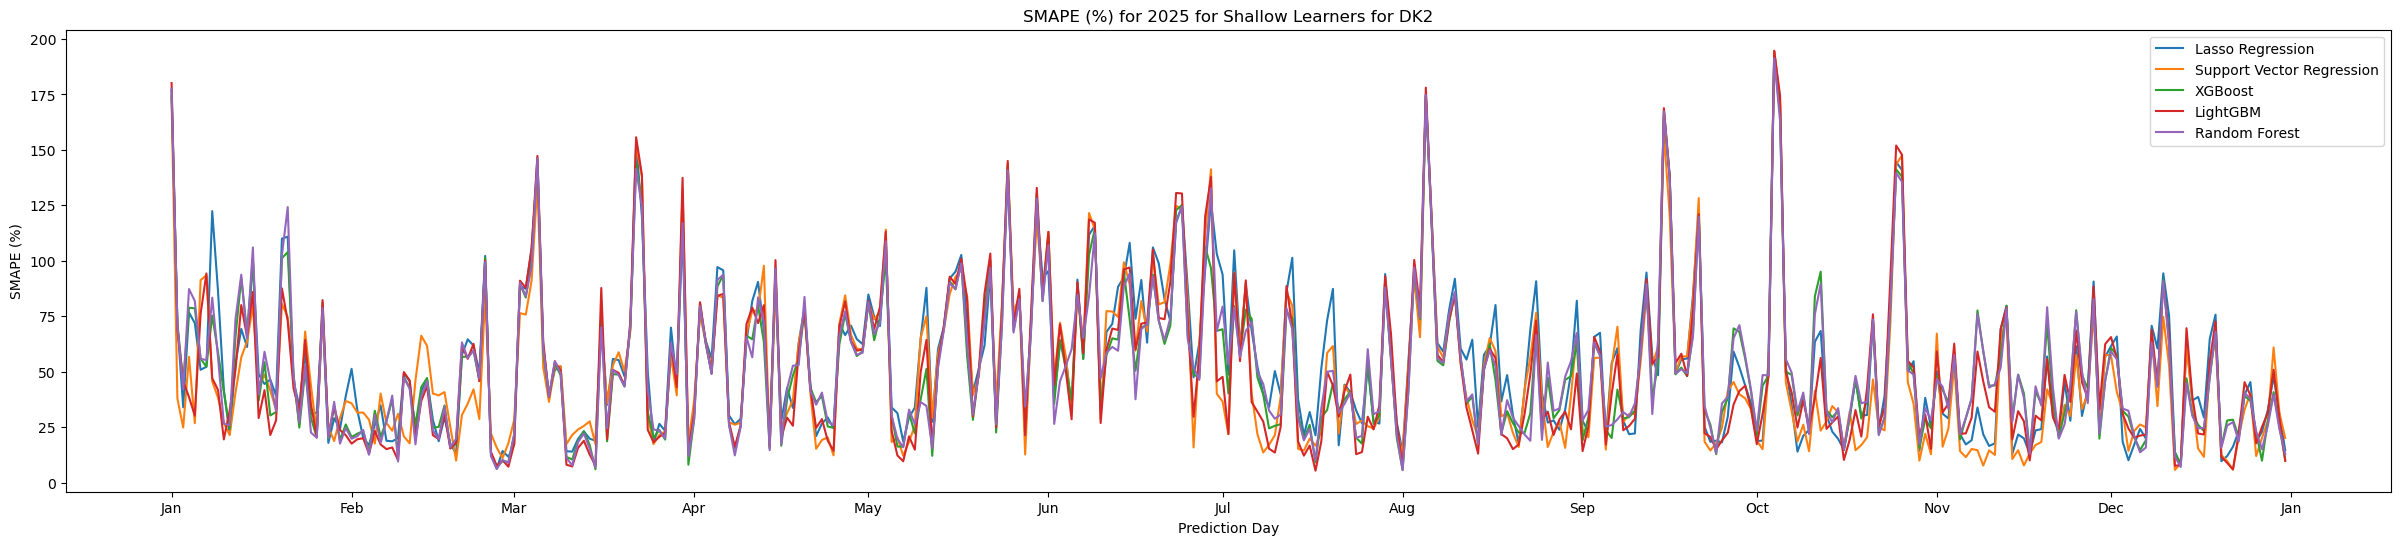

In [57]:
# Generating a plot for shallow DK2 2025 SMAPE

plt.figure(figsize=(30, 6))
plt.plot(xpoints, lasso_DK2_SMAPE, label = "Lasso Regression")
plt.plot(xpoints, SVR_DK2_SMAPE, label = "Support Vector Regression")
plt.plot(xpoints, XGB_DK2_SMAPE, label = "XGBoost")
plt.plot(xpoints, lightgbm_DK2_SMAPE, label = "LightGBM")
plt.plot(xpoints, RF_DK2_SMAPE, label = "Random Forest")
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b'))
plt.xlabel('Prediction Day')
plt.ylabel('SMAPE (%)')
plt.title('SMAPE (%) for 2025 for Shallow Learners for DK2')
plt.legend()
plt.show()